# Linn Preuss Jelvez
# 21-09-2026

In [1]:
import pandas as pd
import numpy as np

# read in data
data_file = "towelData.csv"
data = pd.read_csv(data_file, sep=';', encoding='latin1')
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set 
# can give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

#print(combined_data.shape)
combined_data



,reuse,total,group,study
0,74,211,control,1
1,103,277,control,2
2,77,135,control,3
3,82,187,control,4
4,21,25,control,5
5,123,147,control,6
6,28,30,control,7
7,98,222,social,1
8,587,1318,social,2
9,406,655,social,3


## Model
### Data 
For each of the 7 studies, $j$, there is a control group and a social-norm group. Let $y_{ij}$ be the number of guests who reused their towel, in group $i$ of study $j$. The total number of guests is $n_{ij}$ guests. Let $x_{ij}=1$ for the social-norm group and $0$ for control. 

### Likelihood
The response is a count of success out of a known number of guests. Therefore I use a binomial distribution with a logic link. 
$y_{ij} | p_{ij} \sim \text{Binomial}(n_{ij}, p_{ij}), \hspace{1cm} \text{logit}(p_{ij}) = \beta_0 + u_{0j} + (\beta_1 + u_{1j})x_{ij}$.

### Random effects
$u_{0j} \sim N(0,\tau_0)$ and $u_{1j} \sim N(0,\tau_1)$.

### Priors
$\beta_0 \sim N(0,1.5), \beta_1 \sim N(0,1), \tau_0, \tau_1 \sim \text{HalfNormal}(1)$.

### Interpretation
$\beta_1$ is the average effect of the social-norm message on the log-odds of reuse. $\tau_1$ measures how much that effect varies between each study. 

## Justification
### Binomial with ligic link
Counts out of known totals and the probabilities have to stay between 0 and 1. A normal model would not respect that, like the penguin example in lecture. 

### Hierarchical structure
The observations come from 7 different studies so I expect the results within each study to vary less than the results across studies. Treating them as independent would underestimate uncertainty. 

### Random intercept and slope
Control reuse range from around 35% to 93%, so I assume the baselines differ. 
The effect of the message differs by study. I want between-study heterogenety and to share the information between studies. 

### Priors
- $\beta_0 \sim N(0, 1.5)$: a 95% prior range of about ±3 on the log-odds scale corresponds to a baseline reuse probability between roughly 5% and 95%.
- $\beta_1 \sim N(0, 1)$: centred at no effect, with a 95% range of odds ratios from about 0.14 to 7.4. This allows for a large effect in either direction and does not favour $H_1$ over $H_0$.
- $\tau_0, \tau_1 \sim \text{HalfNormal}(1)$: these must be positive. A scale of 1 on the logit scale allows for differences between studies.


In [2]:
import bambi as bmb
import arviz as az
import numpy as np

priors = { "Intercept": bmb.Prior("Normal",mu=0, sigma=1.5),
           "group": bmb.Prior("Normal", mu=0, sigma=1),
           "1|study": bmb.Prior("Normal", mu=0, sigma= bmb.Prior("HalfNormal", sigma =1)),
           "group|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1)),
}

model = bmb.Model("p(reuse, total) ~ group + (group|study)",
                  data= combined_data, family="binomial", priors=priors)
print(model)

       Formula: p(reuse, total) ~ group + (group|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
            group|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))


In [3]:
idata = model.fit(draws=2000, tune=2000, chains=4, target_accept=0.95, random_seed=1)
#print(list(idata.posterior.data_vars))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset, group|study_sigma, group|study_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 7 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


In [4]:
az.summary(idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.44,0.39,-0.17,1.1,1844,2259,1.00,0.0091,0.006
group[social],0.177,0.13,-0.024,0.35,3377,2846,1.00,0.0029,0.0056
1|study_sigma,1.02,0.306,0.63,1.6,2060,2975,1.00,0.0065,0.0046
group|study_sigma[social],0.165,0.16,0.011,0.47,2435,2980,1.00,0.0035,0.0049
1|study[1],-0.98,0.4,-1.6,-0.35,1913,2432,1.00,0.0092,0.0059
1|study[2],-0.91,0.4,-1.5,-0.29,1869,2442,1.00,0.0092,0.0061
1|study[3],-0.15,0.4,-0.8,0.49,1939,2488,1.00,0.0091,0.0059
1|study[4],-0.66,0.4,-1.3,-0.026,1897,2283,1.00,0.0091,0.0059
1|study[5],1.1,0.51,0.32,1.9,2924,4037,1.00,0.0095,0.0058
1|study[6],0.99,0.41,0.36,1.7,1956,2567,1.00,0.0092,0.0059


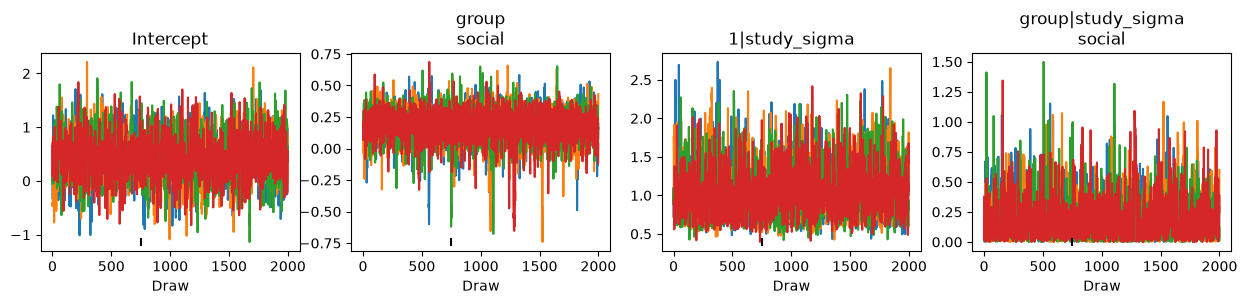

In [5]:
az.plot_trace(idata, var_names=["Intercept", "group", "1|study_sigma", "group|study_sigma"])

In [6]:
import numpy as np
import pandas as pd

post= idata.posterior
def summarize(name):
    x = post[name].values.flatten()
    return {"mean": x.mean(), "5%": np.quantile(x, 0.05), "95%": np.quantile(x,0.95)}

table = pd.DataFrame({n: summarize(n) for n in 
                      ["Intercept", "group", "1|study_sigma", "group|study_sigma"]}).T
table

,mean,5%,95%
Intercept,0.443884,-0.196540,1.089224
group,0.177021,-0.034384,0.357713
1|study_sigma,1.023664,0.625982,1.602883
group|study_sigma,0.165382,0.010386,0.484267


In [7]:
#hypothesis test

beta1 = idata.posterior["group"].values.flatten()
p_H0 = (beta1 <= 0).mean()
print("P(H0 | data) = ", p_H0)
print("P(H1 | data) =" , 1-p_H0)

#effects as an odds ratio
OR = np.exp(beta1)
print(OR.mean(), np.quantile(OR, [0.05, 0.95]))

P(H0 | data) =  0.0695
P(H1 | data) = 0.9305
1.2034788537338756 [0.96620077 1.43005496]


### Hypothesis test
$H_0: \beta_1 \le 0$ (message decreases reuse) against $H_1: \beta_1 > 0$ (message increases reuse)

The posterior probability of $H_0$ is 0.072, so $P(H_1 \mid \text{data}) = 0,928$. The posterior mean of $\beta_1 $ is 0.18 (90% interval -0.04 to 0.36), corresponding to an odds ratio of about 1.21. 
The data therefore support that the social-norm message increases towel reuse, but evidence is not conclusive. The interval includes zero and there is no threshold for Bayesian p-value. If one used 0.05, $H_0$ would not be rejected, but the posterior probability of an effect is high. 

### Diagnostics
The model was sampled with NUTS (4 chains, 2000 tuning, 2000 posterior draws each). With the default settings there were 35 divergent transitions, so I increased "target_accept" to 0.95, which left only 1 divergence. All parameters have $\hat{R} = 1.00$ and effectivesample sizes above 2300. I consider the posterior estimates reliable. 

In [8]:
results ={}
for s in [0.5, 1, 2]:
    pri = {
        "Intercept": bmb.Prior("Normal", mu=0, sigma=1.5),
        "group": bmb.Prior("Normal", mu=0, sigma=1),
        "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=s)),
        "group|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=s)),
    }
    m= bmb.Model("p(reuse, total) ~ group + (group |study)",
    data= combined_data, family="binomial", priors=pri)
    idt = m.fit(draws=2000, tune=2000, chains=4, target_accept=0.95, random_seed=1)
    b= idt.posterior["group"].values.flatten()
    results[s] = (b.mean(), np.quantile(b,0.05), np.quantile(b,0.95),(b<=0).mean())

pd.DataFrame(results, index=["mean", "5%", "95%", "P(H0)"]).T

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset, group|study_sigma, group|study_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset, group|study_sigma, group|study_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 7 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset, group|study_sigma, group|study_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.


,mean,5%,95%,P(H0)
0.5,0.189572,0.005867,0.357692,0.045375
1.0,0.177021,-0.034384,0.357713,0.069500
2.0,0.175154,-0.052698,0.362749,0.081625


## Discussion 
The model estimate that the social-norm message increases the odds of towel reuse by about 21% on average ($\hat\beta_1 = 0.18$, 90% interval $-0.04$ to $0.36$; odds ratio 1.21, 90% interval 0.97 to 1.43). The posterior probability that the message has a positive effect is 0.93. Baseline reuse rates differ substantially between studies ($\hat\tau_0 \approx 1.0$ on the logit scale), which justifies the random intercept. The between-study heterogeneity in the effect itself is small, which is not surprising with 7 studies. A prior sensitivity check showed the posterior mean of $\beta_1$ and the upper end of its interval are stable, while $P(H_0\mid\text{data})$ ranges from 0.05 to 0.08. 

### Limitations
Having only 7 studies available, from the same paper is a limitation as they may not be fully independent. 